Loading the dataset

In [4]:
import pandas as pd
import numpy as np

data_frame1=pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")
data_frame2=pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [6]:
#joinig both sheets
df1=pd.concat([data_frame1,data_frame2], ignore_index=True)

Step 2 : Ckeaning data

In [7]:
df1.dropna(subset=["Customer ID"],inplace=True)

# removing missing rows
df1.dropna(subset=["Description"],inplace=True)

#removing cancle trasenction
df1=df1[~df1["Invoice"].astype(str).str.startswith("C")]

#removing rows with zero or negative quatity
df1=df1[df1["Quantity"]>0]

#removing rows wiht zero or negative price
df1=df1[df1["Price"]>0]

#reset index after cleaning
df1.reset_index(drop=True,inplace=True)

print("\nShape after cleaning:",df1.shape)
print("\nMissing values after cleaning:")
print(df1.isnull().sum())

print("\nData types:")
print(df1.dtypes)


Shape after cleaning: (805549, 8)

Missing values after cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


Step 3: data preprocessing

In [8]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

#converting customer id to integer
df1["Customer ID"]=df1["Customer ID"].astype(int)

#encoding the country column
le=LabelEncoder()
df1["Country_Encoded"]=le.fit_transform(df1["Country"])

print("Unique countries encoded:",df1["Country"].nunique())
print(df1[["Country","Country_Encoded"]].drop_duplicates().head(10))

#creating totalspend column
df1["TotalSpend"]=df1["Quantity"]*df1["Price"]

#scaling
scaler=MinMaxScaler()

df1[["Quantity_Scaled", "Price_Scaled", "TotalSpend_Scaled"]]=scaler.fit_transform(
    df1[["Quantity", "Price", "TotalSpend"]]
)

print("\nSample of scaled features:")
print(df1[["Quantity", "Quantity_Scaled", "Price", "Price_Scaled", "TotalSpend", "TotalSpend_Scaled"]].head())

Unique countries encoded: 41
             Country  Country_Encoded
0     United Kingdom               38
71            France               13
126              USA               36
173          Belgium                3
178        Australia                0
408             EIRE               10
543          Germany               14
1782        Portugal               28
3748         Denmark                9
4420     Netherlands               24

Sample of scaled features:
   Quantity  Quantity_Scaled  Price  Price_Scaled  TotalSpend  \
0        12         0.000136   6.95      0.000634        83.4   
1        12         0.000136   6.75      0.000616        81.0   
2        12         0.000136   6.75      0.000616        81.0   
3        48         0.000580   2.10      0.000192       100.8   
4        24         0.000284   1.25      0.000114        30.0   

   TotalSpend_Scaled  
0           0.000495  
1           0.000481  
2           0.000481  
3           0.000598  
4           0.00017

Step 4: Trasnforming data into binary formate

In [25]:
#here we need to create customer*product matrix
# 1 for if cystomer bought that product else 0

TOP_N_PRODUCT=100

top_products=df1["StockCode"].value_counts().head(TOP_N_PRODUCT).index.tolist()

#ilter data to include top product
df_filtered=df1[df1["StockCode"].isin(top_products)]

#creating binary product matrix
customer_product_matrix=df_filtered.groupby(["Customer ID", "StockCode"])["Quantity"].sum().unstack(fill_value=0)

#6Binarize:if quantity>0,mark as 1 (purchased),else 0
customer_product_matrix = (customer_product_matrix > 0).astype(int)

print("Customer-Product Matrix Shape:", customer_product_matrix.shape)
print("(Rows = Customers, Columns = Products)\n")
print(customer_product_matrix.iloc[:5, :10])  
print("\nSparsity of matrix:")
total_cells = customer_product_matrix.shape[0] * customer_product_matrix.shape[1]
purchased_cells = customer_product_matrix.values.sum()
sparsity = 1 - (purchased_cells / total_cells)
print(f"  Total cells: {total_cells}")
print(f"  Purchased (1s): {purchased_cells}")
print(f"  Sparsity: {sparsity:.2%}")

Customer-Product Matrix Shape: (5368, 100)
(Rows = Customers, Columns = Products)

StockCode    20685  20719  20724  20725  20726  20727  20728  20914  20971  \
Customer ID                                                                  
12346            1      0      0      0      0      0      0      0      0   
12347            0      1      0      0      0      0      0      0      0   
12348            0      0      0      0      0      0      0      0      0   
12349            1      0      0      0      0      0      0      1      0   
12350            0      0      0      0      0      0      0      0      0   

StockCode    20972  
Customer ID         
12346            0  
12347            0  
12348            0  
12349            0  
12350            0  

Sparsity of matrix:
  Total cells: 536800
  Purchased (1s): 64079
  Sparsity: 88.06%


Step 4:training the boltzmann machine

In [10]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn


In [11]:
data=customer_product_matrix.values.astype(np.float32)

#training and spliting into 80-20
split=int(0.8 * len(data))
train_data=data[:split]
test_data=data[split:]

train_tensor = torch.tensor(train_data)
test_tensor = torch.tensor(test_data)

train_loader=DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
print(f"Visible units (products): {data.shape[1]}")

Training samples: 4440
Testing samples: 1111
Visible units (products): 200


In [21]:
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))

    def sample_hidden(self, v):
        wx = torch.mm(v, self.W.t())
        activation = wx + self.h_bias
        p_h_given_v = torch.sigmoid(activation)
        return p_h_given_v, torch.bernoulli(p_h_given_v)

    def sample_visible(self, h):
        wh = torch.mm(h, self.W)
        activation = wh + self.v_bias
        p_v_given_h = torch.sigmoid(activation)
        return p_v_given_h, torch.bernoulli(p_v_given_h)

    def contrastive_divergence(self, v, k=1):   # ← must be INSIDE the class
        p_h0, h0 = self.sample_hidden(v)
        hk = h0
        for _ in range(k):
            p_vk, vk = self.sample_visible(hk)
            p_hk, hk = self.sample_hidden(vk)
        positive_grad = torch.mm(p_h0.t(), v)
        negative_grad = torch.mm(p_hk.t(), vk)
        return positive_grad - negative_grad, v, vk

    def forward(self, v):
        p_h, h = self.sample_hidden(v)
        p_v, v_reconstructed = self.sample_visible(h)
        return v_reconstructed

    def reconstruction_error(self, v):
        v_reconstructed = self.forward(v)
        return torch.mean((v - v_reconstructed) ** 2).item()

In [26]:
#initialize and train the RBM
N_VISIBLE = data.shape[1]
N_HIDDEN = 50               
LEARNING_RATE = 0.1         
EPOCHS = 50               
BATCH_SIZE = 64            
# Rebuild DataLoader with new batch size
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)

rbm = RBM(n_visible=N_VISIBLE, n_hidden=N_HIDDEN)
optimizer = optim.SGD(rbm.parameters(), lr=LEARNING_RATE, momentum=0.9)  # ← Added momentum

train_errors = []
test_errors = []

print("\nStarting RBM Training...\n")


Starting RBM Training...



In [27]:
for epoch in range(1, EPOCHS + 1):
    rbm.train()

    for (batch,) in train_loader:
        grad, v, vk = rbm.contrastive_divergence(batch, k=1)

        # Update weights using CD gradients directly
        with torch.no_grad():
            rbm.W.grad = -grad / batch.shape[0]
            rbm.v_bias.grad = -torch.mean(v - vk, dim=0)
            rbm.h_bias.grad = -(torch.mean(
                rbm.sample_hidden(v)[0] - rbm.sample_hidden(vk)[0], dim=0
            ))

        optimizer.step()
        optimizer.zero_grad()

    rbm.eval()
    with torch.no_grad():
        train_err = rbm.reconstruction_error(train_tensor)
        test_err = rbm.reconstruction_error(test_tensor)

    train_errors.append(train_err)
    test_errors.append(test_err)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Error: {train_err:.6f} | Test Error: {test_err:.6f}")

Epoch   1/50 | Train Error: 0.158499 | Test Error: 0.147309
Epoch  10/50 | Train Error: 0.119961 | Test Error: 0.115230
Epoch  20/50 | Train Error: 0.108354 | Test Error: 0.106796
Epoch  30/50 | Train Error: 0.104892 | Test Error: 0.104793
Epoch  40/50 | Train Error: 0.104143 | Test Error: 0.103708
Epoch  50/50 | Train Error: 0.103348 | Test Error: 0.103884


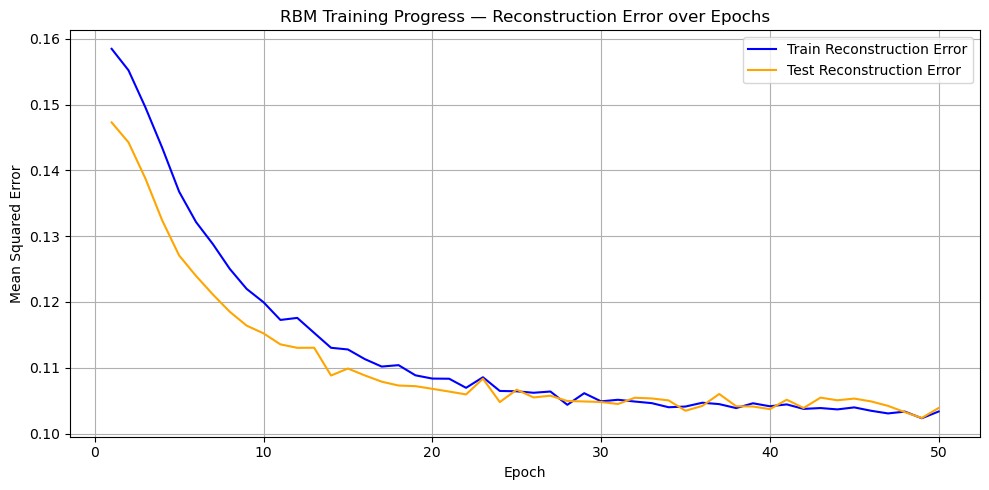

Plot saved as 'rbm_training_progress.png'


In [28]:
#ploting training progrss
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_errors, label="Train Reconstruction Error", color="blue")
plt.plot(range(1, EPOCHS + 1), test_errors, label="Test Reconstruction Error", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("RBM Training Progress — Reconstruction Error over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("rbm_training_progress.png", dpi=150)
plt.show()
print("Plot saved as 'rbm_training_progress.png'")

Step 6:Analyze Customer Segments 

Hidden representation shape: (4440, 50)
Each customer is now represented by 50 latent features

Customer Segments (K=4):
  Segment 0: 847 customers
  Segment 1: 1733 customers
  Segment 2: 938 customers
  Segment 3: 922 customers


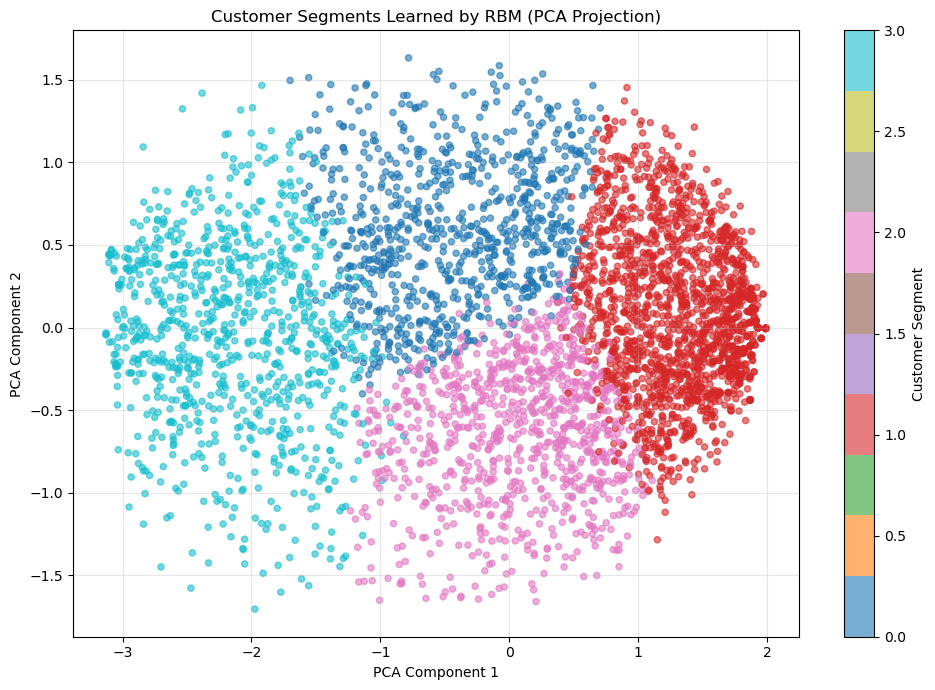

Segment plot saved as 'customer_segments.png'

--- Observations ---
1. The RBM learned a compressed hidden representation of customer shopping habits.
2. Customers in the same segment tend to buy similar products.
3. Lower reconstruction error means the RBM effectively models the purchase distribution.
4. PCA visualization shows distinct clusters, confirming segment separability.


In [30]:
from sklearn.cluster import KMeans
import seaborn as sns

# Extract hidden representations (latent features) for each customer
rbm.eval()
with torch.no_grad():
    hidden_probs, _ = rbm.sample_hidden(train_tensor)
    hidden_features = hidden_probs.numpy()

print("Hidden representation shape:", hidden_features.shape)
print("Each customer is now represented by", hidden_features.shape[1], "latent features")

# Use KMeans to cluster customers into segments
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(hidden_features)

print(f"\nCustomer Segments (K={N_CLUSTERS}):")
unique, counts = np.unique(cluster_labels, return_counts=True)
for seg, count in zip(unique, counts):
    print(f"  Segment {seg}: {count} customers")

# Visualize using PCA (reduce to 2D for plotting)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(hidden_features)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=20)
plt.colorbar(scatter, label="Customer Segment")
plt.title("Customer Segments Learned by RBM (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("customer_segments.png", dpi=150)
plt.show()
print("Segment plot saved as 'customer_segments.png'")

# --- Observations ---
print("\n--- Observations ---")
print("1. The RBM learned a compressed hidden representation of customer shopping habits.")
print("2. Customers in the same segment tend to buy similar products.")
print("3. Lower reconstruction error means the RBM effectively models the purchase distribution.")
print("4. PCA visualization shows distinct clusters, confirming segment separability.")